In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 基礎設定 ---
# 定義 Q1~Q4 對應的固定顏色
qubit_colors = {
    "Q1": '#9bbf8a',
    "Q2": '#92afda',
    "Q3": '#f79059',
    "Q4": '#c82423'
}

temperatures = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 125, 130, 140,145, 150,155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 210] # mK

qubits_to_plot = ["Q1",  "Q3", "Q4"]
qubit_frequency = [3620.63506, 4029.170438, 3127.600198, 3311.82327] # MHz
all_data = []


成功讀取: qubit_results_10mK.csv
成功讀取: qubit_results_20mK.csv
成功讀取: qubit_results_30mK.csv
成功讀取: qubit_results_40mK.csv
成功讀取: qubit_results_50mK.csv
成功讀取: qubit_results_60mK.csv
成功讀取: qubit_results_70mK.csv
成功讀取: qubit_results_80mK.csv
成功讀取: qubit_results_90mK.csv
成功讀取: qubit_results_100mK.csv
成功讀取: qubit_results_110mK.csv
成功讀取: qubit_results_120mK.csv
成功讀取: qubit_results_125mK.csv
成功讀取: qubit_results_130mK.csv
成功讀取: qubit_results_140mK.csv
成功讀取: qubit_results_145mK.csv
成功讀取: qubit_results_150mK.csv
成功讀取: qubit_results_155mK.csv
成功讀取: qubit_results_160mK.csv
成功讀取: qubit_results_165mK.csv
成功讀取: qubit_results_170mK.csv
成功讀取: qubit_results_175mK.csv
成功讀取: qubit_results_180mK.csv
成功讀取: qubit_results_185mK.csv
成功讀取: qubit_results_190mK.csv
成功讀取: qubit_results_195mK.csv
成功讀取: qubit_results_200mK.csv
成功讀取: qubit_results_210mK.csv


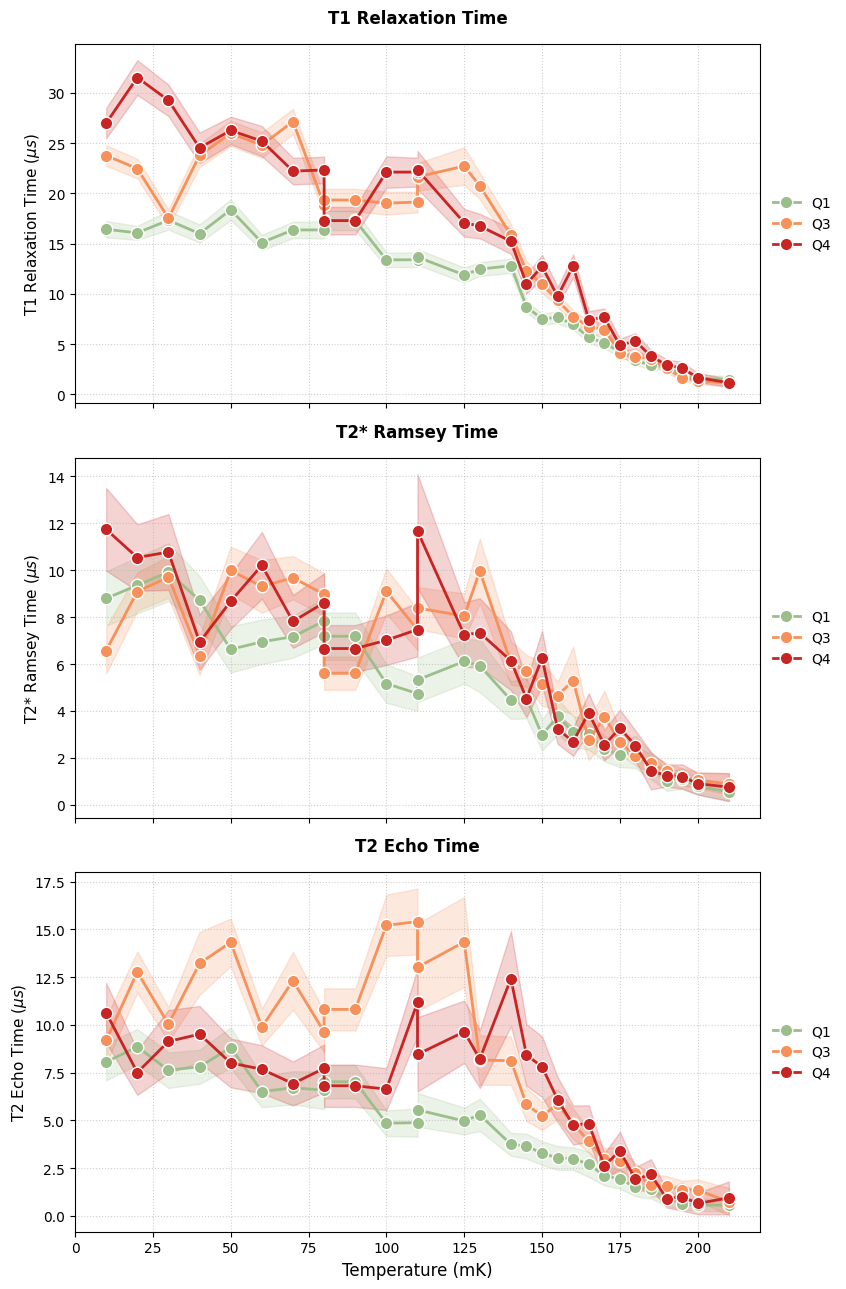

In [3]:

# --- 2. 讀取數據 ---
for temp in temperatures:
    file_path = f"qubit_results_{temp}mK.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if not df.empty:
            all_data.append(df)
            print(f"成功讀取: {file_path}")
    else:
        print(f"找不到檔案: {file_path}")

if len(all_data) == 0:
    print("❌ 錯誤：沒有讀取到任何數據！")
else:
    df_total = pd.concat(all_data, ignore_index=True)

    # --- 3. 開始繪圖 ---
    # 定義子圖指標 (欄位名, 誤差欄位名, 顯示標題)
    metrics = [
        ('t1_time', 't1_err', 'T1 Relaxation Time'),
        ('t2r_time', 't2r_err', 'T2* Ramsey Time'),
        ('t2e_time', 't2e_err', 'T2 Echo Time')
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 13), sharex=True)

    for i, (val_col, err_col, title) in enumerate(metrics):
        ax = axes[i]
        
        for q in qubits_to_plot:
            # 挑選資料
            q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
            if q_df.empty:
                continue

            # 取得該 Qubit 專屬顏色
            q_color = qubit_colors.get(q, '#000000') # 預設黑色
            
            # 轉換數據格式
            temp_x = q_df['temp_mK'].values
            y_vals = pd.to_numeric(q_df[val_col], errors='coerce').values
            y_errs = pd.to_numeric(q_df[err_col], errors='coerce').fillna(0).values
            
            # 畫出 Qubit 的中心線與點
            ax.plot(temp_x, y_vals, 'o-', label=f'{q}', color=q_color, 
                    markersize=9, linewidth=2, markeredgecolor='white', markeredgewidth=1)
            
            # 畫出 Qubit 的 Error Band (誤差帶)
            ax.fill_between(temp_x, y_vals - y_errs, y_vals + y_errs, 
                            color=q_color, alpha=0.2)

        # 子圖美化
        ax.set_ylabel(f"{title} ($\mu s$)", fontsize=11)
        ax.set_title(title, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False) # 標籤放在右側

    axes[-1].set_xlabel("Temperature (mK)", fontsize=12)
    
    # 調整間距以容納右側 Legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.85) 
    plt.show()

<Figure size 1000x700 with 0 Axes>

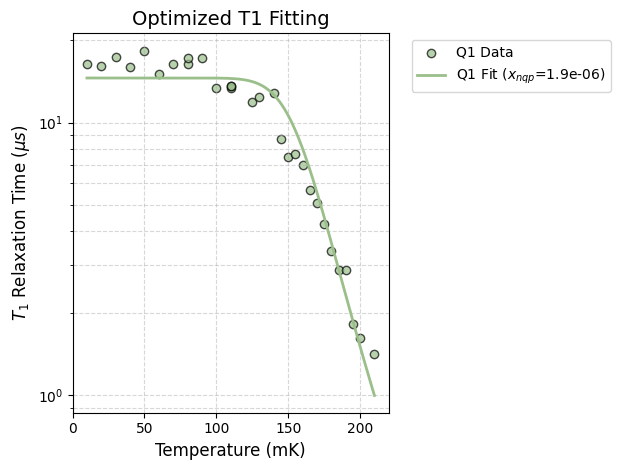

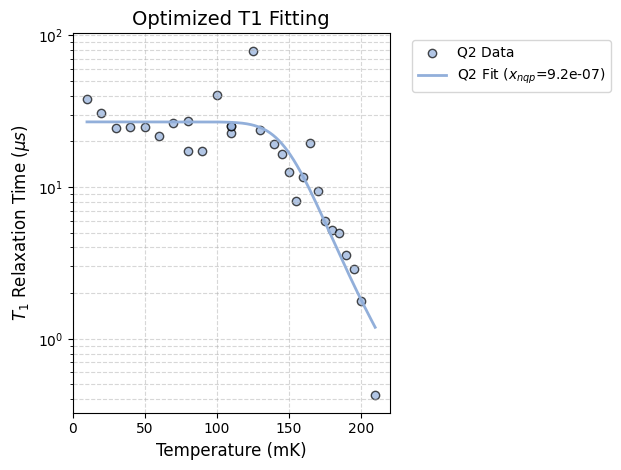

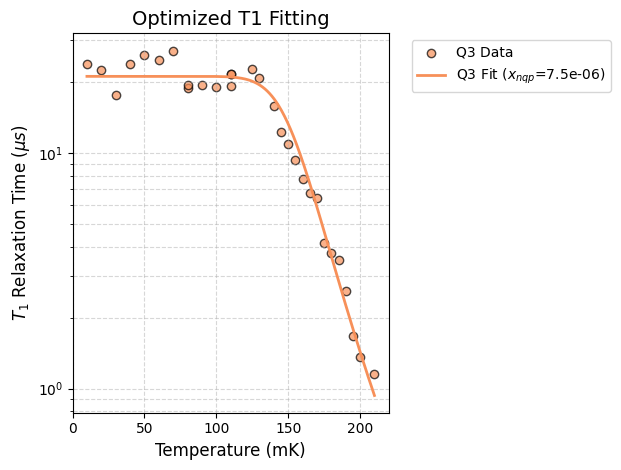

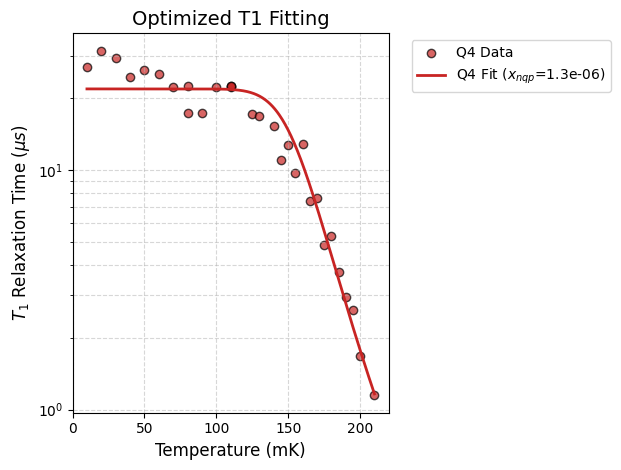

[Q1 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 20.2 us
----------------------------------------
[Q2 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 19.2 us
----------------------------------------
[Q3 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 21.6 us
----------------------------------------
[Q4 Fit Results]
  Optimized x_nqp : 1.33e-06
  Current n_qp   : 8.2505 μm⁻³
  T1 Limit (T->0): 21.8 us
  T2 Limit (T->0): 21.1 us
----------------------------------------


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
DELTA_UEV = 180 

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    # 增加 epsilon 防止 T=0 報錯
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp


def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
plt.figure(figsize=(10, 7))

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # 優化點 1: 更精確的初始猜測
        # Gamma_bg 猜測最低溫度的速率
        g_bg_init = rate_data.min()
        # scale_factor 理論值大約在 10^2 ~ 10^3 之間
        
        # 優化點 2: 使用對數擬合以提高低溫段準確度
        popt, _ = curve_fit(log_qp_rate_model, T_data, log_rate_data, 
                            p0=[g_bg_init, 800, 1e-7], 
                            bounds=([0, 1, 1e-10], [1, 1e5, 1e-4]),
                            maxfev=10000)
        
        g_bg, s_fit, x_nqp_fit = popt
        plt.figure()
        # 繪圖
        plt.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        rate_fit = qp_rate_model(T_fit, *popt)
        plt.plot(T_fit, 1/rate_fit, '-', color=qubit_colors[q], linewidth=2,
                 label=f'{q} Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) # 近似 T=0
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

    plt.yscale('log')
    plt.xlabel("Temperature (mK)", fontsize=12)
    plt.ylabel("$T_1$ Relaxation Time ($\mu s$)", fontsize=12)
    plt.title("Optimized T1 Fitting", fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # 180 ueV 轉為 eV

for q in ["Q1", "Q2", "Q3", "Q4"]:
    try:
        g_bg, s_fit, x_nqp_fit = popt
        n_qp_current = 2 * N0_AL * DELTA_EV * x_nqp_fit
        # --- 計算 T2 Limit ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        t1_limit = 1 / qp_rate_model(1e-6, *popt) 
        gamma_phi_nqp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_nqp_fit
        rate_t2_limit = (1 / (2 * t1_limit)) + (2 * np.pi * gamma_phi_nqp)
        t2_limit = 1 / rate_t2_limit

        print(f"[{q} Fit Results]")
        print(f"  Optimized x_nqp : {x_nqp_fit:.2e}")
        print(f"  Current n_qp   : {n_qp_current:.4f} μm⁻³") # <-- 新增這行
        print(f"  T1 Limit (T->0): {t1_limit:.1f} us")
        print(f"  T2 Limit (T->0): {t2_limit:.1f} us")
        print("-" * 40)
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")


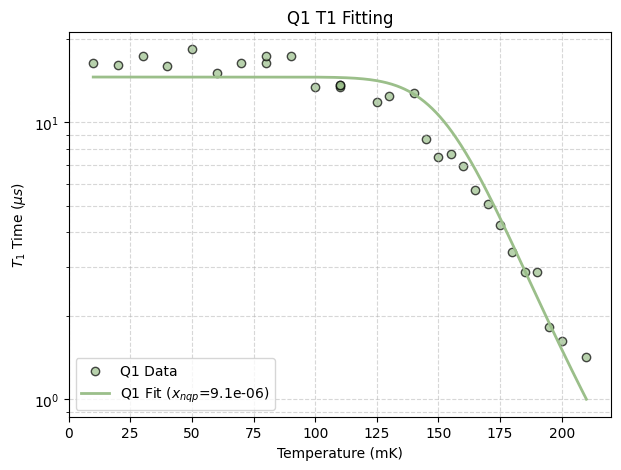

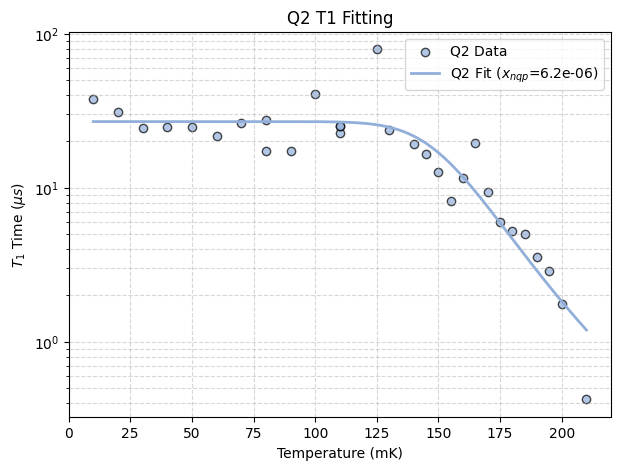

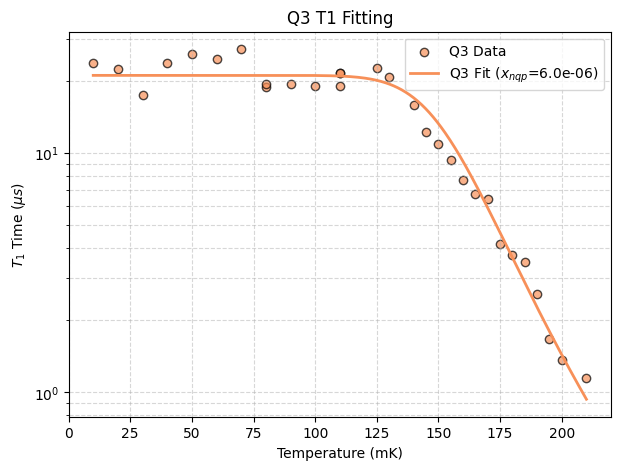

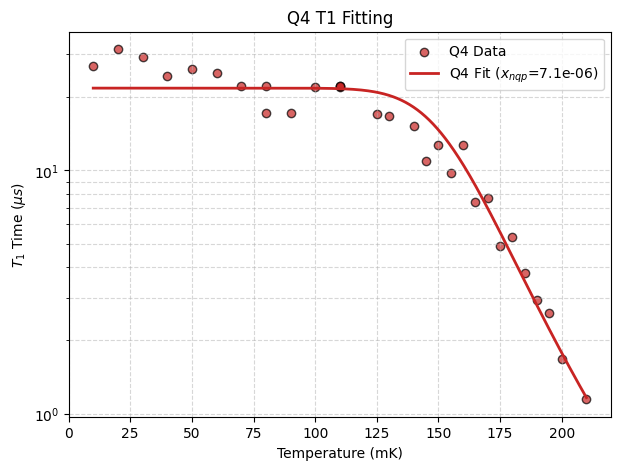


Qubit    | Fit x_nqp    | T1_pred (μs)  | T2_pred (μs) 
         |              | (@20mK)       | (@20mK)      
----------------------------------------------------------------------
Note: Predictions assume ideal x_nqp = 5.00e-08 and temperature = 20 mK
Q1       | 9.10e-06     | 60.2          | 107.5        
Q2       | 6.21e-06     | 150.6         | 226.5        
Q3       | 5.95e-06     | 98.4          | 168.0        
Q4       | 7.07e-06     | 94.1          | 160.5        


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數與模型 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
N0_AL = 1.72e10   # 1/eV/um^3
DELTA_EV = 180e-6 # eV

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp

def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    # 使用對數擬合對低溫數據更敏感
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
fit_results_dict = {} 

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # --- [優化核心]：自動推導初始值與邊界 ---
        # 取得數據中的最低速率 (通常發生在最低溫)
        min_observed_rate = rate_data.min()
        
        # 1. Gamma_bg 初始猜測：假設一半的低溫速率來自背景
        g_bg_init = min_observed_rate * 0.5
        
        # 2. scale_factor 初始猜測：根據高溫段斜率大致估算 (通常在 500-1500 間)
        s_init = 1000 
        
        # 3. x_nqp 初始猜測：根據剩下的另一半速率回推
        x_nqp_init = (min_observed_rate * 0.5) / s_init

        # 設定嚴格邊界：Gamma_bg 絕不能超過目前觀測到的總速率
        # 這樣擬合器就不會無腦把所有衰減都丟給背景，而忽略準粒子
        lower_bounds = [0, 10, 1e-12]
        upper_bounds = [min_observed_rate * 1.1, 1e5, 1e-4]

        popt, pcov = curve_fit(
            log_qp_rate_model, T_data, log_rate_data, 
            p0=[g_bg_init, s_init, x_nqp_init], 
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )
        
        fit_results_dict[q] = popt
        g_bg, s_fit, x_nqp_fit = popt
        
        # 繪圖
        plt.figure(figsize=(7, 5))
        plt.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        rate_fit_vals = qp_rate_model(T_fit, *popt)
        plt.plot(T_fit, 1/rate_fit_vals, '-', color=qubit_colors[q], linewidth=2,
                 label=f'{q} Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        
        plt.yscale('log')
        plt.xlabel("Temperature (mK)")
        plt.ylabel("$T_1$ Time ($\mu s$)")
        plt.title(f"{q} T1 Fitting")
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.legend()
        plt.show()
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

# --- 3. 預測功能 ---
def predict_qubit_performance(target_q, ideal_temp_mK, ideal_x_nqp):
    if target_q not in fit_results_dict:
        return None
    
    g_bg, s_fit, _ = fit_results_dict[target_q]
    f_ge = qubit_freqs[target_q]
    wp = f_ge + EC
    
    # 理想總 x_qp
    term_sqrt = np.sqrt(2 * np.pi * ideal_temp_mK / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / ideal_temp_mK)
    x_qp_total = ideal_x_nqp + term_sqrt * term_exp
    
    # 預測 T1 與 T2
    rate_t1 = g_bg + s_fit * x_qp_total
    t1_pred = 1 / rate_t1
    gamma_phi_qp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_total
    rate_t2 = (1 / (2 * t1_pred)) + (2 * np.pi * gamma_phi_qp)
    
    return {"T1": t1_pred, "T2": 1/rate_t2, "n_qp": 2 * N0_AL * DELTA_EV * ideal_x_nqp}

# --- 4. 輸出與手動預測 ---
IDEAL_X_NQP = 5e-8 
IDEAL_TEMP = 20 

print("\n" + "="*70)
print(f"{'Qubit':<8} | {'Fit x_nqp':<12} | {'T1_pred (μs)':<13} | {'T2_pred (μs)':<13}")
print(f"{'':<8} | {'':<12} | {'(@' + str(IDEAL_TEMP) + 'mK)':<13} | {'(@' + str(IDEAL_TEMP) + 'mK)':<13}")
print("-" * 70)
print(f"Note: Predictions assume ideal x_nqp = {IDEAL_X_NQP:.2e} and temperature = {IDEAL_TEMP} mK")
for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q in fit_results_dict:
        popt = fit_results_dict[q]
        pred = predict_qubit_performance(q, IDEAL_TEMP, IDEAL_X_NQP)
        print(f"{q:<8} | {popt[2]:.2e}     | {pred['T1']:<13.1f} | {pred['T2']:<13.1f}")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數與換算因子 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
# 鋁的換算因子: n_qp = x_qp * (2 * N0 * Delta)
# 根據 Barends (2011), 2 * N0 * Delta 約為 6.19e6 um^-3
NQP_CONV = 6.192e6 

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp

def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
fit_results_dict = {} 

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = q_df['t1_time'].values
    rate_data = 1 / T1_data
    
    try:
        min_observed_rate = rate_data.min()
        g_bg_init = min_observed_rate * 0.5
        s_init = 1000 
        x_nqp_init = (min_observed_rate * 0.5) / s_init

        lower_bounds = [0, 10, 1e-12]
        upper_bounds = [min_observed_rate * 1.1, 1e5, 1e-4]

        popt, _ = curve_fit(
            log_qp_rate_model, T_data, np.log10(rate_data), 
            p0=[g_bg_init, s_init, x_nqp_init], 
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )
        fit_results_dict[q] = popt
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

# --- 3. 預測功能 (帶入 n_qp 計算) ---
def predict_performance(target_q, ideal_temp_mK, ideal_x_nqp):
    if target_q not in fit_results_dict: return None
    g_bg, s_fit, _ = fit_results_dict[target_q]
    f_ge = qubit_freqs[target_q]
    wp = f_ge + EC
    
    # 理想總 x_qp 與 n_qp
    term_sqrt = np.sqrt(2 * np.pi * ideal_temp_mK / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / ideal_temp_mK)
    x_qp_total = ideal_x_nqp + term_sqrt * term_exp

    # 預測 T1/T2
    t1_pred = 1 / (g_bg + s_fit * x_qp_total)
    gamma_phi_qp = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_total
    t2_pred = 1 / ((1 / (2 * t1_pred)) + (2 * np.pi * gamma_phi_qp))
    
    return {"T1": t1_pred, "T2": t2_pred}

# --- 4. 最終表格輸出 ---
IDEAL_X_NQP = 5e-8 
IDEAL_TEMP = 20 

print("\n" + "="*95)
print(f"{'Qubit':<6} | {'Fit x_nqp':<10} | {'Fit n_qp':<10} | {'T1_pred':<10} | {'T2_pred':<10} | {'n_qp_pred':<10}")
print(f"{'':<6} | {'(Residual)':<10} | {'(um^-3)':<10} | {'(μs)':<10} | {'(μs)':<10} | {'(um^-3)'}")
print("-" * 95)
print(f"Prediction Target: Temp = {IDEAL_TEMP} mK, x_nqp = {IDEAL_X_NQP:.1e}")
print("-" * 95)

for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q in fit_results_dict:
        popt = fit_results_dict[q]
        x_nqp_fit = popt[2]
        n_qp_fit = x_nqp_fit * NQP_CONV
        pred = predict_performance(q, IDEAL_TEMP, IDEAL_X_NQP)
        
        print(f"{q:<6} | {x_nqp_fit:.2e} | {n_qp_fit:<10.2f} | {pred['T1']:<10.1f} | {pred['T2']:<10.1f} ")
print("="*95)


Qubit  | Fit x_nqp  | Fit n_qp   | T1_pred    | T2_pred    | n_qp_pred 
       | (Residual) | (um^-3)    | (μs)       | (μs)       | (um^-3)
-----------------------------------------------------------------------------------------------
Prediction Target: Temp = 20 mK, x_nqp = 5.0e-08
-----------------------------------------------------------------------------------------------
Q1     | 9.10e-06 | 56.34      | 60.2       | 107.5      
Q2     | 6.21e-06 | 38.48      | 150.6      | 226.5      
Q3     | 5.95e-06 | 36.87      | 98.4       | 168.0      
Q4     | 7.07e-06 | 43.79      | 94.1       | 160.5      


In [7]:
def nqp_to_xqp(n_qp):
    """
    將實體密度 n_qp (um^-3) 換算為歸一化比例 x_qp
    """
    # 根據 Barends (2011) 參數：conversion_factor = 2 * N0 * Delta
    # N0 = 1.72e10 (1/eV/um^3), Delta = 1.8e-4 (eV)
    conversion_factor = 6.192e6 
    return n_qp / conversion_factor

nqp_to_xqp(10)

1.6149870801033591e-06

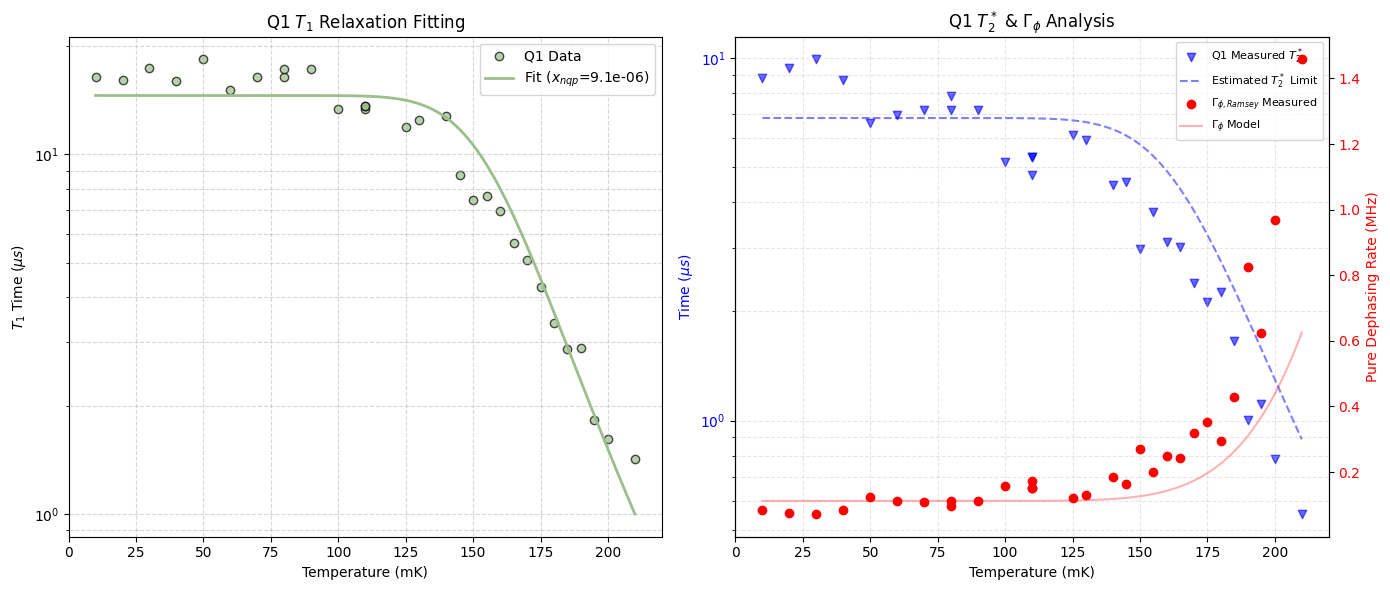

[Q1 Fit Results]
  Residual x_nqp : 9.10e-06
  Residual n_qp  : 56.3417 μm⁻³
----------------------------------------


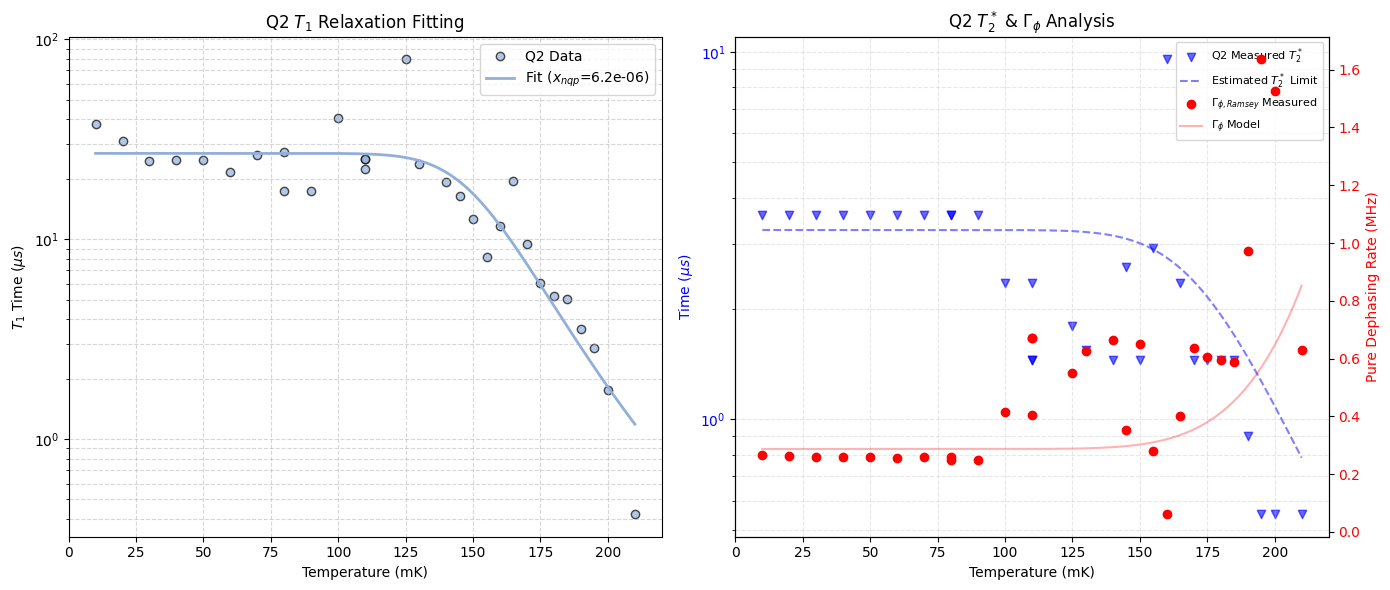

[Q2 Fit Results]
  Residual x_nqp : 6.21e-06
  Residual n_qp  : 38.4767 μm⁻³
----------------------------------------


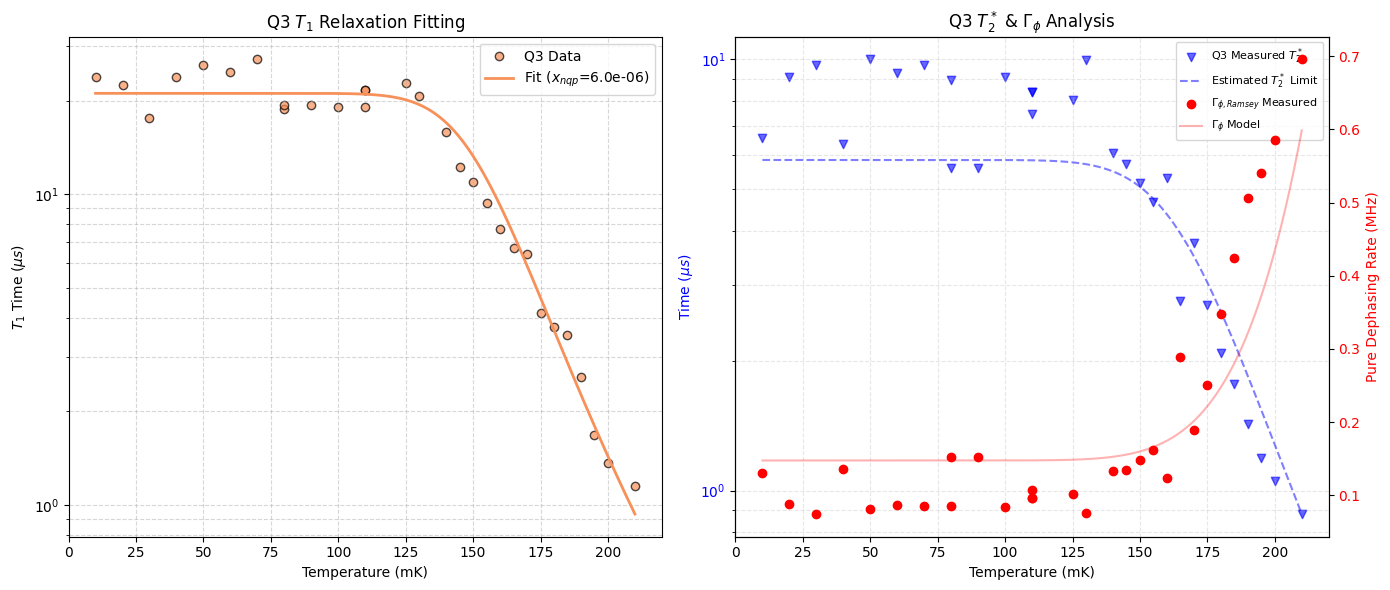

[Q3 Fit Results]
  Residual x_nqp : 5.95e-06
  Residual n_qp  : 36.8662 μm⁻³
----------------------------------------


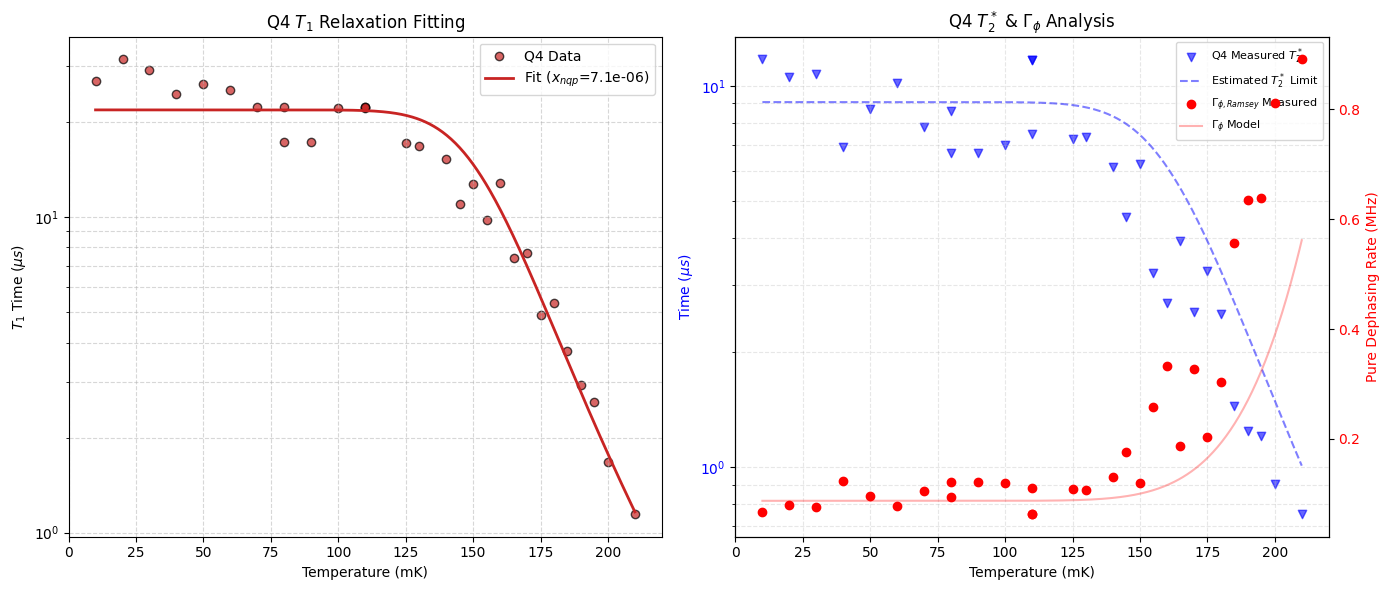

[Q4 Fit Results]
  Residual x_nqp : 7.07e-06
  Residual n_qp  : 43.7884 μm⁻³
----------------------------------------


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# --- 1. 物理常數與模型 ---
qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} 
EC = 200 
DELTA_KB = 1800 
N0_AL = 1.72e10   
DELTA_EV = 180e-6 
NQP_CONV = 6.192e6 # x_qp to n_qp conversion

def qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    T = np.maximum(T, 1e-6)
    term_sqrt = np.sqrt(2 * np.pi * T / DELTA_KB)
    term_exp = np.exp(-DELTA_KB / T)
    x_qp = x_nqp + term_sqrt * term_exp
    return Gamma_bg + scale_factor * x_qp

def log_qp_rate_model(T, Gamma_bg, scale_factor, x_nqp):
    return np.log10(qp_rate_model(T, Gamma_bg, scale_factor, x_nqp))

# --- 2. 核心分析與繪圖 ---
fit_results_dict = {} 

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_data = q_df['temp_mK'].values
    T1_data = pd.to_numeric(q_df['t1_time'], errors='coerce').values
    T2r_data = pd.to_numeric(q_df['t2r_time'], errors='coerce').values
    
    # 過濾有效數據
    mask = ~np.isnan(T1_data) & ~np.isnan(T2r_data)
    T_data, T1_data, T2r_data = T_data[mask], T1_data[mask], T2r_data[mask]
    rate_data = 1 / T1_data
    log_rate_data = np.log10(rate_data)
    
    try:
        # --- 使用你指定的舊版優化核心進行 T1 擬合 ---
        min_observed_rate = rate_data.min()
        g_bg_init = min_observed_rate * 0.5
        s_init = 1000 
        x_nqp_init = (min_observed_rate * 0.5) / s_init

        lower_bounds = [0, 10, 1e-12]
        upper_bounds = [min_observed_rate * 1.1, 1e5, 1e-4]

        popt, pcov = curve_fit(
            log_qp_rate_model, T_data, log_rate_data, 
            p0=[g_bg_init, s_init, x_nqp_init], 
            bounds=(lower_bounds, upper_bounds),
            maxfev=50000
        )
        fit_results_dict[q] = popt
        g_bg, s_fit, x_nqp_fit = popt

        # --- 計算理論預測與實測 Gamma_phi ---
        f_ge = qubit_freqs[q]
        wp = f_ge + EC
        T_line = np.linspace(T_data.min(), T_data.max(), 500)
        
        # 理論 x_qp 與 Gamma_phi (基於 Kamenov/Cai 2024)
        x_qp_line = x_nqp_fit + np.sqrt(2 * np.pi * T_line / DELTA_KB) * np.exp(-DELTA_KB / T_line)
        gamma_phi_qp_theory = (np.pi / 4) * f_ge * (wp / f_ge)**2 * x_qp_line
        
        # 實測 Gamma_phi = 1/T2r - 1/(2*T1)
        gamma_phi_measured = (1 / T2r_data) - (1 / (2 * T1_data))
        
        # 擬合出的 T1 與 T2 理論線
        rate_t1_line = qp_rate_model(T_line, *popt)
        t1_fit_line = 1 / rate_t1_line
        # 注意：此處 T2 理論線包含低溫殘餘 dephasing (假設來自低溫第一點的 Gamma_phi)
        g_phi_0 = gamma_phi_measured[0] if len(gamma_phi_measured) > 0 else 0
        t2_fit_line = 1 / ((rate_t1_line / 2) + g_phi_0 + gamma_phi_qp_theory)

        # --- 繪圖邏輯：左右並列 ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        # 左圖：獨立 T1 擬合
        ax1.scatter(T_data, T1_data, color=qubit_colors[q], label=f'{q} Data', alpha=0.7, edgecolors='k')
        ax1.plot(T_line, t1_fit_line, '-', color=qubit_colors[q], linewidth=2,
                 label=f'Fit ($x_{{nqp}}$={x_nqp_fit:.1e})')
        ax1.set_yscale('log')
        ax1.set_xlabel("Temperature (mK)")
        ax1.set_ylabel("$T_1$ Time ($\mu s$)")
        ax1.set_title(f"{q} $T_1$ Relaxation Fitting")
        ax1.grid(True, which="both", ls="--", alpha=0.5)
        ax1.legend()

        # 右圖：T2 Ramsey 與 Gamma Phi
        ax2.scatter(T_data, T2r_data, color='blue', marker='v', label=f'{q} Measured $T_2^*$', alpha=0.6)
        ax2.plot(T_line, t2_fit_line, 'b--', alpha=0.5, label='Estimated $T_2^*$ Limit')
        ax2.set_yscale('log')
        ax2.set_xlabel("Temperature (mK)")
        ax2.set_ylabel("Time ($\mu s$)", color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        
        # 右圖次座標軸：Gamma Phi
        ax2_twin = ax2.twinx()
        ax2_twin.plot(T_data, gamma_phi_measured, 'ro', label='$\Gamma_{\phi, Ramsey}$ Measured')
        ax2_twin.plot(T_line, gamma_phi_qp_theory + g_phi_0, 'r-', alpha=0.3, label='$\Gamma_{\phi}$ Model')
        ax2_twin.set_ylabel("Pure Dephasing Rate (MHz)", color='red')
        ax2_twin.tick_params(axis='y', labelcolor='red')
        
        ax2.set_title(f"{q} $T_2^*$ & $\Gamma_\phi$ Analysis")
        ax2.grid(True, which="both", ls="--", alpha=0.3)
        
        # 合併 Legend
        lines, labels = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=8)

        plt.tight_layout()
        plt.show()

        # 輸出結果
        n_qp_current = x_nqp_fit * NQP_CONV
        print(f"[{q} Fit Results]")
        print(f"  Residual x_nqp : {x_nqp_fit:.2e}")
        print(f"  Residual n_qp  : {n_qp_current:.4f} μm⁻³")
        print("-" * 40)
        
    except Exception as e:
        print(f"{q} Fitting Error: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.constants import k, e

# --- 1. 物理常數固定 (鋁的本質屬性) ---
DELTA_UEV = 180.0  
DELTA_KB = (DELTA_UEV * 1e-6 * e / k) * 1000 # 換算為 mK
NQP_CONV = 6.192e6 # x_qp 轉 n_qp 因子 [cite: 43, 306]
EC = 200 

qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8}

def get_thermal_xqp(T):
    """熱平衡準粒子比例公式 [cite: 56, 731]"""
    T = np.maximum(T, 1e-6)
    return np.sqrt(2 * np.pi * T / DELTA_KB) * np.exp(-DELTA_KB / T)

# --- 2. 核心分析與獨立擬合 ---
for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_d = q_df['temp_mK'].values
    T1_d = pd.to_numeric(q_df['t1_time'], errors='coerce').values
    T2r_d = pd.to_numeric(q_df['t2r_time'], errors='coerce').values
    
    # 過濾無效點，確保計算 Gamma_phi 時兩者都有數據 [cite: 298, 300]
    mask = ~np.isnan(T1_d) & ~np.isnan(T2r_d)
    T_d, T1_d, T2r_d = T_d[mask], T1_d[mask], T2r_d[mask]
    
    rate_t1_data = 1 / T1_d
    gamma_phi_data = (1/T2r_d) - (1/(2*T1_d)) # 實測純去相干率 [cite: 300, 302]
    
    f_ge = qubit_freqs[q]
    dephasing_scale_theory = (np.pi / 4) * f_ge * ((f_ge + EC) / f_ge)**2 # Kamenov 理論係數

    try:
        # --- [獨立擬合 1: T1 Relaxation] ---
        def t1_fit_func(T, g_bg, s, x_nqp):
            return np.log10(g_bg + s * (x_nqp + get_thermal_xqp(T)))
        
        popt_t1, _ = curve_fit(t1_fit_func, T_d, np.log10(rate_t1_data), 
                               p0=[rate_t1_data.min()*0.5, 1000, 1e-7],
                               bounds=([0, 10, 1e-12], [rate_t1_data.max(), 1e5, 1e-4]))
        g_bg_f, s_t1_f, x_nqp_t1 = popt_t1

        # --- [獨立擬合 2: Gamma_phi Dephasing] ---
        # 這裡完全不使用 popt_t1 的結果，讓擬合器重新尋找最適合 T2 數據的密度
        def phi_fit_func(T, g_phi_0, s_phi, x_nqp_p):
            return np.log10(np.maximum(g_phi_0 + s_phi * (x_nqp_p + get_thermal_xqp(T)), 1e-10))
        
        popt_phi, _ = curve_fit(phi_fit_func, T_d, np.log10(np.maximum(gamma_phi_data, 1e-10)), 
                                p0=[gamma_phi_data.min(), dephasing_scale_theory, 1e-7],
                                bounds=([0, 1, 1e-12], [1.0, 1e5, 1e-4]))
        g_phi_0_f, s_phi_f, x_nqp_phi = popt_phi

        # --- 3. 繪圖佈局 (左右獨立) ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        T_line = np.linspace(T_d.min(), T_d.max(), 500)
        x_thermal_line = get_thermal_xqp(T_line)

        # 左圖：T1 獨立擬合
        t1_fit_line = 1 / (g_bg_f + s_t1_f * (x_nqp_t1 + x_thermal_line))
        ax1.scatter(T_d, T1_d, color=qubit_colors[q], alpha=0.7, edgecolors='k', label='Measured $T_1$')
        ax1.plot(T_line, t1_fit_line, '-', color=qubit_colors[q], linewidth=2.5, label='Independent $T_1$ Fit')
        ax1.set_yscale('log'); ax1.set_xlabel("Temperature (mK)"); ax1.set_ylabel("$T_1$ ($\mu s$)")
        ax1.set_title(f"{q} Energy Relaxation ($T_1$)"); ax1.grid(True, which="both", alpha=0.3); ax1.legend()

        # 右圖：T2* 與 Gamma_phi 獨立分析
        # 注意：此處的 T2 曲線是基於 Tphi 擬合出的密度回推的
        g_phi_fit_line = g_phi_0_f + s_phi_f * (x_nqp_phi + x_thermal_line)
        # 為了畫出 T2 曲線，我們仍需 1/2T1，這裡使用實測 T1 的平滑化版本以確保圖形美觀
        t2_fit_line = 1 / ((1/(2*t1_fit_line)) + g_phi_fit_line)
        
        ax2.scatter(T_d, T2r_d, color='blue', marker='v', alpha=0.5, label='Measured $T_2^*$')
        ax2.plot(T_line, t2_fit_line, 'b--', linewidth=1.5, label='Independent $T_2^*$ Fit')
        ax2.set_yscale('log'); ax2.set_ylabel("Time ($\mu s$)", color='blue')
        
        ax2_twin = ax2.twinx()
        ax2_twin.plot(T_d, gamma_phi_data, 'ro', markersize=5, label='Measured $\Gamma_\phi$')
        ax2_twin.plot(T_line, g_phi_fit_line, 'r-', alpha=0.3, label='Independent $\Gamma_\phi$ Fit')
        ax2_twin.set_ylabel("Dephasing Rate (MHz)", color='red')
        
        ax2.set_title(f"{q} Dephasing Analysis ($\Gamma_\phi$)"); ax2.set_xlabel("Temperature (mK)")
        h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(h1+h2, l1+l2, loc='upper right', fontsize=8); ax2.grid(True, which="both", alpha=0.3)

        plt.tight_layout(); plt.show()

        # --- 4. 輸出完全獨立的擬合參數 ---
        print(f"[{q} Independent Fit Results]")
        print(f"  >> Relaxation Channel (T1):")
        print(f"     Residual x_nqp : {x_nqp_t1:.2e} ({x_nqp_t1*NQP_CONV:.4f} μm⁻³)")
        print(f"     Gamma_bg       : {g_bg_f:.5f} MHz")
        print(f"  >> Dephasing Channel (Phi):")
        print(f"     Residual x_nqp : {x_nqp_phi:.2e} ({x_nqp_phi*NQP_CONV:.4f} μm⁻³)")
        print(f"     Gamma_phi_0    : {g_phi_0_f:.5f} MHz")
        print(f"  >> Comparison:")
        print(f"     x_nqp Ratio (Phi/T1): {x_nqp_phi/x_nqp_t1:.2f}x")
        print("-" * 65)

        from scipy.constants import k, e

        # 參數設定
        delta_uev = 180.0
        T = 20.0
        x_nqp = 5e-8
        f_ge = 3620.6  # MHz
        Ec = 200.0     # MHz

        # 1. 精確計算 Delta/kB
        delta_kb = (delta_uev * 1e-6 * e / k) * 1000 # 換算為 mK

        # 2. 計算熱平衡密度 (20mK 下極小)
        x_thermal = np.sqrt(2 * np.pi * T / delta_kb) * np.exp(-delta_kb / T)
        x_total = x_nqp + x_thermal

        # 3. 計算 Dephasing 係數 (Kamenov)
        s_phi = (np.pi / 4) * f_ge * ((f_ge + Ec) / f_ge)**2

        # 4. 假設 T1 轉導係數 s_t1 (通常擬合值在 4e4 ~ 6e4 之間)
        s_t1 = 5e4 

        # 5. 速率計算 (MHz)
        g1 = s_t1 * x_total
        g_phi = s_phi * x_total
        g2_star = (g1 / 2) + g_phi

        print(f"--- Pridict (T=20mK, xqp=5e-8) ---")
        print(f"T1     : {1/g1:.2f} us")
        print(f"T_phi  : {1/g_phi:.2f} us")
        print(f"T2* : {1/g2_star:.2f} us")
    except Exception as e:
        print(f"{q} Fit error: {e}")

[Q1 物理特性與雜訊分析]
  >> 殘留準粒子密度 (x_nqp):
     From T1 Fit    : 2.53e-06 (15.6506 μm⁻³)
     From Phi Fit   : 2.15e-06 (13.3116 μm⁻³)
  >> 背景噪聲項 (Non-QP Noise):
     Gamma_phi_0    : 0.035118 MHz
     T_noise (Limit): 28.48 μs  <-- 背景雜訊壓制的天花板
  >> 預測結果 (@20mK, xqp=5e-8):
     Target T1      : 711.45 μs
     Target T2* : 27.79 μs
-----------------------------------------------------------------
[Q2 物理特性與雜訊分析]
  >> 殘留準粒子密度 (x_nqp):
     From T1 Fit    : 8.32e-07 (5.1529 μm⁻³)
     From Phi Fit   : 7.18e-06 (44.4828 μm⁻³)
  >> 背景噪聲項 (Non-QP Noise):
     Gamma_phi_0    : 0.111620 MHz
     T_noise (Limit): 8.96 μs  <-- 背景雜訊壓制的天花板
  >> 預測結果 (@20mK, xqp=5e-8):
     Target T1      : 53.84 μs
     Target T2* : 8.26 μs
-----------------------------------------------------------------
[Q3 物理特性與雜訊分析]
  >> 殘留準粒子密度 (x_nqp):
     From T1 Fit    : 1.23e-06 (7.5945 μm⁻³)
     From Phi Fit   : 1.06e-06 (6.5763 μm⁻³)
  >> 背景噪聲項 (Non-QP Noise):
     Gamma_phi_0    : 0.077177 MHz
     T_noise (Limit): 12.96 μs 

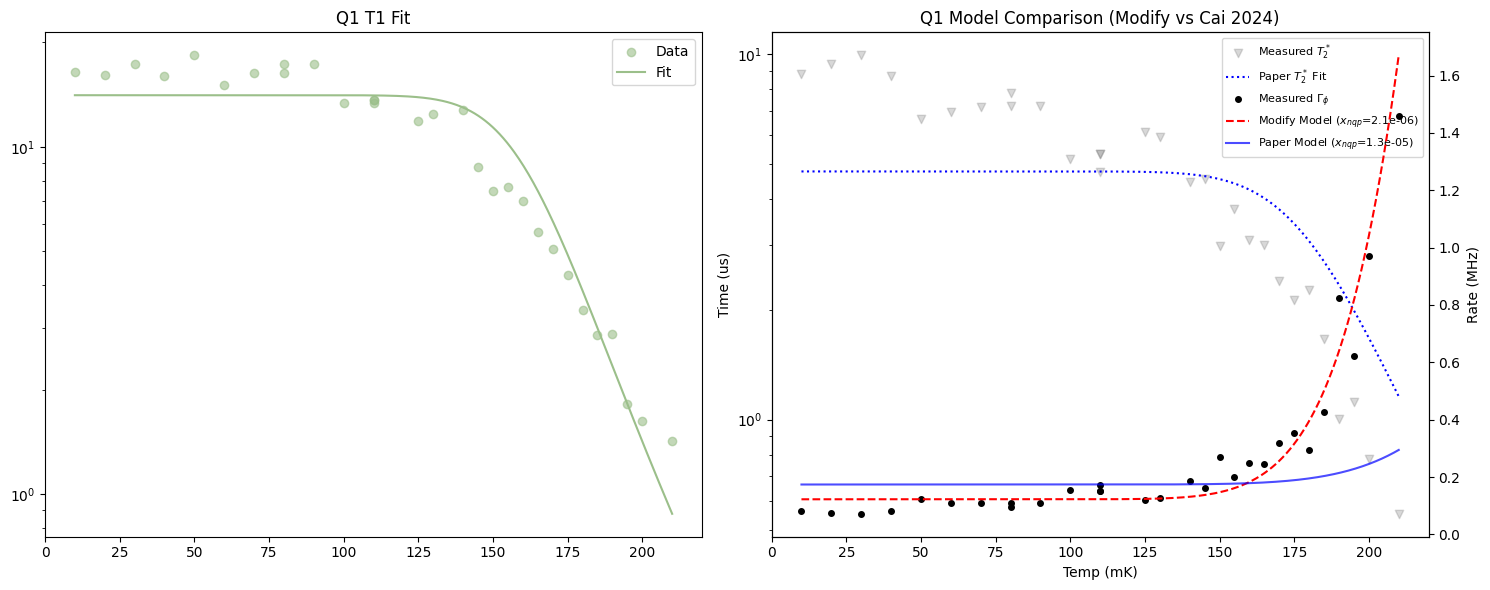

[Q1 擬合模型對比報告]
  理論係數 (s_phi_theory) : 3166.45
  Modify 擬合係數 (s_phi) : 40677.70
----------------------------------------
  x_nqp (T1 Baseline)     : 2.53e-06
  x_nqp (Modify Model)    : 2.15e-06 (Ratio to T1: 0.85x)
  x_nqp (Paper Model)     : 1.30e-05 (Ratio to T1: 5.15x)
  Residual Noise Floor    : 0.132870 MHz
-----------------------------------------------------------------


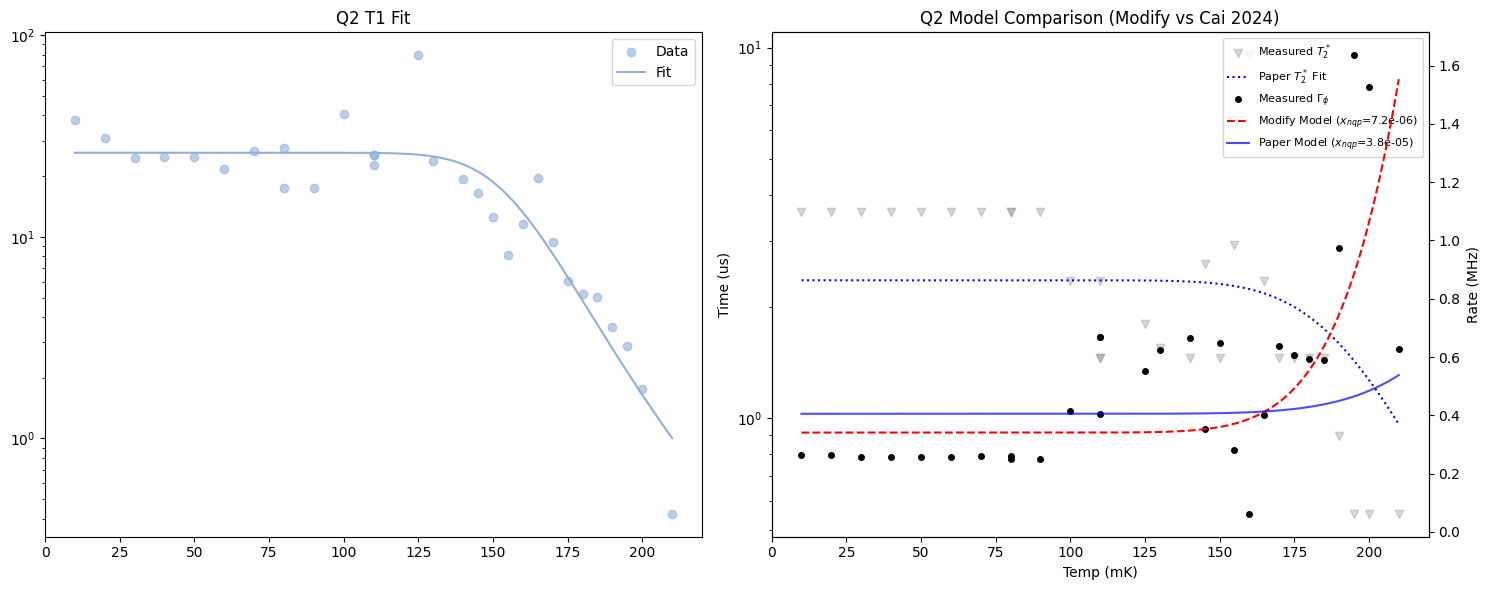

[Q2 擬合模型對比報告]
  理論係數 (s_phi_theory) : 3486.40
  Modify 擬合係數 (s_phi) : 31875.59
----------------------------------------
  x_nqp (T1 Baseline)     : 8.32e-07
  x_nqp (Modify Model)    : 7.18e-06 (Ratio to T1: 8.63x)
  x_nqp (Paper Model)     : 3.76e-05 (Ratio to T1: 45.16x)
  Residual Noise Floor    : 0.274184 MHz
-----------------------------------------------------------------


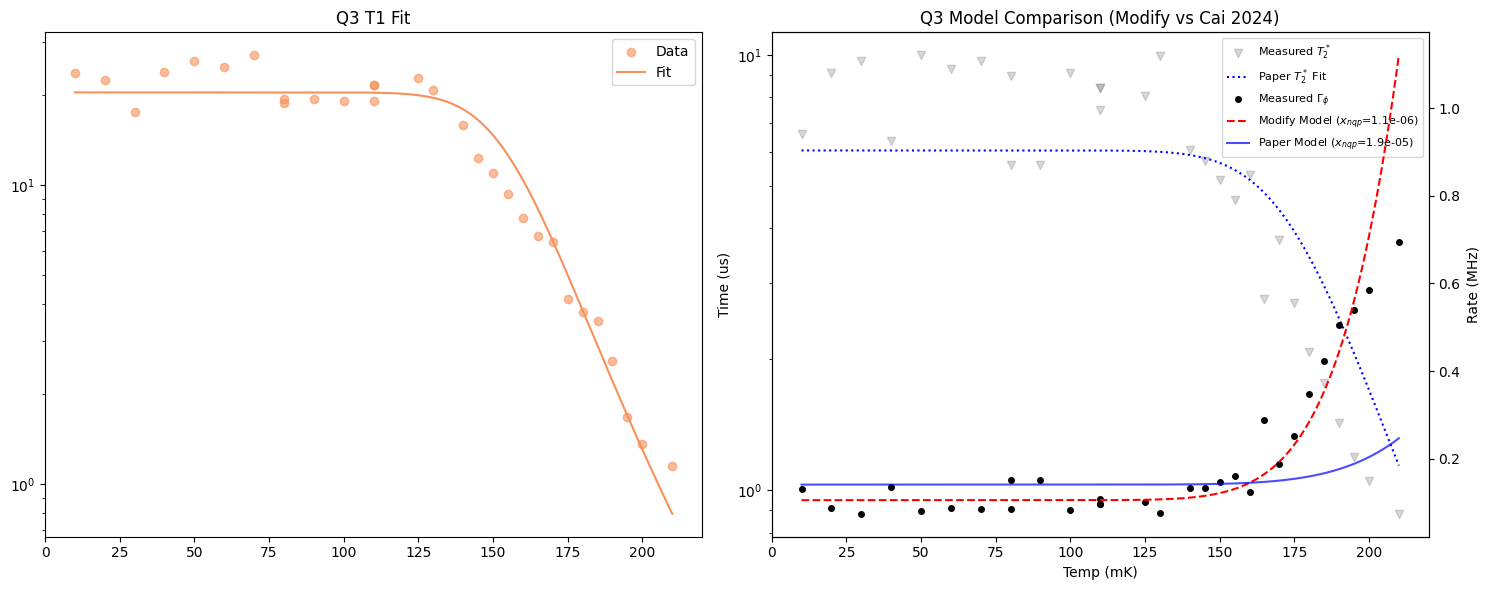

[Q3 擬合模型對比報告]
  理論係數 (s_phi_theory) : 2780.62
  Modify 擬合係數 (s_phi) : 26680.18
----------------------------------------
  x_nqp (T1 Baseline)     : 1.23e-06
  x_nqp (Modify Model)    : 1.06e-06 (Ratio to T1: 0.87x)
  x_nqp (Paper Model)     : 1.85e-05 (Ratio to T1: 15.10x)
  Residual Noise Floor    : 0.089544 MHz
-----------------------------------------------------------------


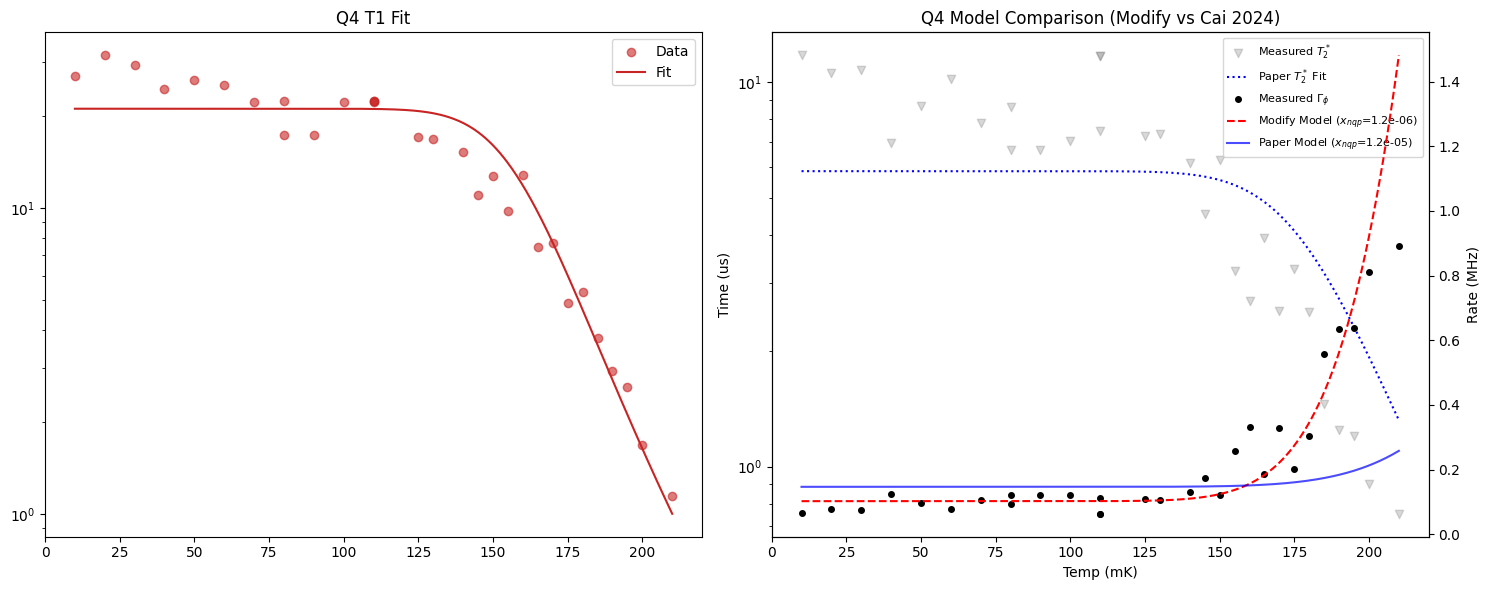

[Q4 擬合模型對比報告]
  理論係數 (s_phi_theory) : 2924.73
  Modify 擬合係數 (s_phi) : 36245.35
----------------------------------------
  x_nqp (T1 Baseline)     : 1.23e-06
  x_nqp (Modify Model)    : 1.17e-06 (Ratio to T1: 0.95x)
  x_nqp (Paper Model)     : 1.16e-05 (Ratio to T1: 9.40x)
  Residual Noise Floor    : 0.112863 MHz
-----------------------------------------------------------------


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.constants import k, e

# --- 1. 物理常數與全域參數 ---
DELTA_UEV = 180.0  
DELTA_KB = (DELTA_UEV * 1e-6 * e / k) * 1000 
NQP_CONV = 6.192e6 
EC = 200 

qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8}

def get_thermal_xqp(T):
    """計算熱平衡準粒子比例"""
    T = np.maximum(T, 1e-6)
    return np.sqrt(2 * np.pi * T / DELTA_KB) * np.exp(-DELTA_KB / T)

# --- 2. 核心分析與模型比較 ---
for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue
    
    T_d = q_df['temp_mK'].values
    T1_d = pd.to_numeric(q_df['t1_time'], errors='coerce').values
    T2r_d = pd.to_numeric(q_df['t2r_time'], errors='coerce').values
    
    mask = ~np.isnan(T1_d) & ~np.isnan(T2r_d)
    T_d, T1_d, T2r_d = T_d[mask], T1_d[mask], T2r_d[mask]
    
    rate_t1_data = 1 / T1_d
    gamma_phi_data = (1/T2r_d) - (1/(2*T1_d))
    
    f_ge = qubit_freqs[q]
    s_phi_theory = (np.pi / 4) * f_ge * ((f_ge + EC) / f_ge)**2 

    try:
        # --- [擬合 1: T1 Relaxation (Baseline)] ---
        def t1_fit_func(T, g_bg, s, x_nqp):
            return np.log10(np.maximum(g_bg + s * (x_nqp + get_thermal_xqp(T)), 1e-10))
        
        popt_t1, _ = curve_fit(t1_fit_func, T_d, np.log10(rate_t1_data), 
                               p0=[rate_t1_data.min()*0.5, 50000, 1e-7],
                               bounds=([0, 10, 1e-12], [rate_t1_data.max(), 1e6, 1e-4]))
        g_bg_f, s_t1_f, x_nqp_t1_f = popt_t1

        # --- [擬合 2: Modify 模型 (Free s_phi)] ---
        def phi_modify_func(T, g_phi_0, s_phi, x_nqp_p):
            return np.log10(np.maximum(g_phi_0 + s_phi * (x_nqp_p + get_thermal_xqp(T)), 1e-10))
        
        popt_mod, _ = curve_fit(phi_modify_func, T_d, np.log10(np.maximum(gamma_phi_data, 1e-10)), 
                                p0=[gamma_phi_data.min(), s_phi_theory, 1e-7],
                                bounds=([0, 1, 1e-12], [1.0, 1e6, 1e-4]))
        g_phi_0_mod, s_phi_mod, x_nqp_mod = popt_mod

        # --- [擬合 3: Paper 模型 (Fixed s_phi - Cai/Kamenov)] ---
        # 根據 Cai et al. (2024), 去相干項應嚴格遵循物理公式，不應自由擬合係數
        def phi_paper_func(T, g_phi_0, x_nqp_p):
            return np.log10(np.maximum(g_phi_0 + s_phi_theory * (x_nqp_p + get_thermal_xqp(T)), 1e-10))
        
        popt_paper, _ = curve_fit(phi_paper_func, T_d, np.log10(np.maximum(gamma_phi_data, 1e-10)), 
                                  p0=[gamma_phi_data.min(), x_nqp_mod],
                                  bounds=([0, 1e-12], [1.0, 1e-4]))
        g_phi_0_paper, x_nqp_paper = popt_paper

        # --- 3. 繪圖佈局 (三模型對比) ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        T_line = np.linspace(T_d.min(), T_d.max(), 500)
        x_th_line = get_thermal_xqp(T_line)

        # 左圖：T1
        ax1.scatter(T_d, T1_d, color=qubit_colors[q], alpha=0.6, label='Data')
        ax1.plot(T_line, 1/(g_bg_f + s_t1_f*(x_nqp_t1_f + x_th_line)), color=qubit_colors[q], label='Fit')
        ax1.set_yscale('log'); ax1.set_title(f"{q} T1 Fit"); ax1.legend()

        # 右圖：Gamma_phi 模型對比
        ax2_twin = ax2.twinx()
        ax2_twin.plot(T_d, gamma_phi_data, 'ko', markersize=4, label='Measured $\Gamma_\phi$')
        
        # Modify 線
        g_phi_mod_line = g_phi_0_mod + s_phi_mod * (x_nqp_mod + x_th_line)
        ax2_twin.plot(T_line, g_phi_mod_line, 'r--', label=f'Modify Model ($x_{{nqp}}$={x_nqp_mod:.1e})')
        
        # Paper 線
        g_phi_paper_line = g_phi_0_paper + s_phi_theory * (x_nqp_paper + x_th_line)
        ax2_twin.plot(T_line, g_phi_paper_line, 'b-', alpha=0.7, label=f'Paper Model ($x_{{nqp}}$={x_nqp_paper:.1e})')
        
        # 繪製對應的 T2* 趨勢 (以 Paper 模型為例)
        t1_line = 1 / (g_bg_f + s_t1_f*(x_nqp_t1_f + x_th_line))
        t2_paper_line = 1 / ((1/(2*t1_line)) + g_phi_paper_line)
        ax2.scatter(T_d, T2r_d, color='gray', marker='v', alpha=0.3, label='Measured $T_2^*$')
        ax2.plot(T_line, t2_paper_line, 'b:', label='Paper $T_2^*$ Fit')
        
        ax2.set_yscale('log'); ax2.set_ylabel("Time (us)"); ax2_twin.set_ylabel("Rate (MHz)")
        ax2.set_title(f"{q} Model Comparison (Modify vs Cai 2024)"); ax2.set_xlabel("Temp (mK)")
        
        # 合併 Legend
        h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(h1+h2, l1+l2, loc='upper right', fontsize=8)

        plt.tight_layout(); plt.show()

        # --- 4. 輸出比較報告 ---
        print(f"[{q} 擬合模型對比報告]")
        print(f"  理論係數 (s_phi_theory) : {s_phi_theory:.2f}")
        print(f"  Modify 擬合係數 (s_phi) : {s_phi_mod:.2f}")
        print("-" * 40)
        print(f"  x_nqp (T1 Baseline)     : {x_nqp_t1_f:.2e}")
        print(f"  x_nqp (Modify Model)    : {x_nqp_mod:.2e} (Ratio to T1: {x_nqp_mod/x_nqp_t1_f:.2f}x)")
        print(f"  x_nqp (Paper Model)     : {x_nqp_paper:.2e} (Ratio to T1: {x_nqp_paper/x_nqp_t1_f:.2f}x)")
        print(f"  Residual Noise Floor    : {g_phi_0_paper:.6f} MHz")
        print("-" * 65)

    except Exception as e_msg:
        print(f"{q} 分析出錯: {e_msg}")